In [1]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from astropy.coordinates import get_sun
from astropy.time import Time

from utils.plotting import (
    TEXTWIDTH_IN, LW_FINE, LW_GUIDE, NEUTRAL_COLOR, PRIMARY_COLOR, SCATTER_S_FINE,
)

C         = 299792458.0
NCH_LON   = -122.2573   # NCH site longitude (degrees east)
F_S_HZ    = 500e6
F_RF0_HZ  = 9790e6
N_FFT     = 2048
N_CH      = 1024
DF_HZ     = F_S_HZ / N_FFT
F_HZ      = F_RF0_HZ + np.arange(N_CH) * DF_HZ
F_SKY_GHZ = F_HZ / 1e9
PLOT_BAND_GHZ = (9.9, 10.0)

In [2]:
# ---------------------------------------------------------------------------
# Load data, sort chronologically, compute per-capture Sun RA/Dec and HA
# The Sun moves ~1°/day so RA must be recomputed for each capture.
# ---------------------------------------------------------------------------

DATA_DIR = Path('../../data/lab03/sun_calibration')
paths    = sorted(DATA_DIR.glob('*.npz'))
files    = [np.load(p) for p in paths]

def _mid_unix(f):
    if 'unix_time_start' in f:
        return (float(f['unix_time_start']) + float(f['unix_time_end'])) / 2
    return float(f['unix_time'])

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON) % 360.0

def _sun_radec(unix_t):
    """Returns (ra_deg, dec_deg) of the Sun at unix_t via astropy."""
    sun = get_sun(Time(unix_t, format='unix'))
    return sun.ra.deg, sun.dec.deg

# Sort by midpoint timestamp
unix_mid  = np.array([_mid_unix(f) for f in files])
order     = np.argsort(unix_mid)
unix_sort = unix_mid[order]
files_s   = [files[i] for i in order]
t_rel     = unix_sort - unix_sort[0]

# Per-capture Sun RA, Dec, HA
sun_ra_arr  = np.zeros(len(files_s))
sun_dec_arr = np.zeros(len(files_s))
for i, t in enumerate(unix_sort):
    sun_ra_arr[i], sun_dec_arr[i] = _sun_radec(t)

lst_arr = np.array([_lst_deg(t) for t in unix_sort])
ha_deg  = (lst_arr - sun_ra_arr) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0
ha_rad  = np.deg2rad(ha_deg)

# Global amplitude normalisation
all_amp = np.array([np.abs(f['corr']) for f in files_s])
all_amp[:, 0] = 0.0
AMP_PEAK = all_amp.max()

print(f'Loaded {len(files_s)} captures from {DATA_DIR.resolve()}')
print(f'Time span  : {t_rel[-1]/3600:.2f} hr')
print(f'Sun RA     : {sun_ra_arr.min():.4f}° – {sun_ra_arr.max():.4f}°  '
      f'(span {sun_ra_arr.max()-sun_ra_arr.min():.4f}°)')
print(f'Sun Dec    : {sun_dec_arr.mean():.4f}°  (mean)')
print(f'HA range   : {ha_deg.min():.2f}° → {ha_deg.max():.2f}°  (span {ha_deg.max()-ha_deg.min():.2f}°)')

Loaded 184 captures from /Users/junruiting/GitHub/ay-121/data/lab03/sun_calibration
Time span  : 1.00 hr
Sun RA     : 356.9760° – 357.0141°  (span 0.0381°)
Sun Dec    : -1.3018°  (mean)
HA range   : -61.87° → -46.88°  (span 14.99°)


Passband      : k=256–870  (9.8525–10.0024 GHz)  450 ch
Passband median amp : 0.9260
RFI threshold (2.5×): 2.3150  →  0 flagged channels
Clean channels      : 450


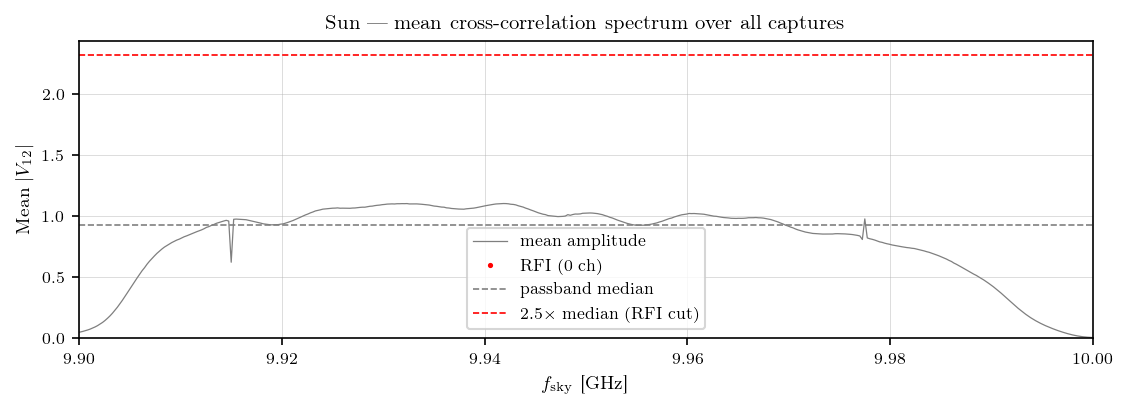

In [3]:
# ---------------------------------------------------------------------------
# Spectral overview: identify passband and flag narrowband RFI
# ---------------------------------------------------------------------------

mean_amp = all_amp.mean(axis=0)

# Passband: channels non-zero in >50% of captures
pb_mask = (all_amp > 0).mean(axis=0) > 0.5
pb_mask[0] = False

# RFI: channels > RFI_SIGMA × passband median
RFI_SIGMA = 2.5
pb_median  = np.median(mean_amp[pb_mask])
rfi_mask   = pb_mask & (mean_amp > RFI_SIGMA * pb_median)
clean_mask = pb_mask & ~rfi_mask

print(f'Passband      : k={np.where(pb_mask)[0].min()}–{np.where(pb_mask)[0].max()}  '
      f'({F_SKY_GHZ[pb_mask].min():.4f}–{F_SKY_GHZ[pb_mask].max():.4f} GHz)  '
      f'{pb_mask.sum()} ch')
print(f'Passband median amp : {pb_median:.4f}')
print(f'RFI threshold ({RFI_SIGMA:.1f}×): {RFI_SIGMA*pb_median:.4f}  →  {rfi_mask.sum()} flagged channels')
print(f'Clean channels      : {clean_mask.sum()}')

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
ax.plot(F_SKY_GHZ, mean_amp, lw=LW_FINE, color=NEUTRAL_COLOR, label='mean amplitude')
ax.plot(F_SKY_GHZ[rfi_mask], mean_amp[rfi_mask], 'r.', ms=3, label=f'RFI ({rfi_mask.sum()} ch)')
ax.axhline(pb_median,             color='gray', lw=LW_GUIDE, ls='--', label='passband median')
ax.axhline(RFI_SIGMA * pb_median, color='red',  lw=LW_GUIDE, ls='--', label=f'{RFI_SIGMA:.1f}× median (RFI cut)')
ax.set_xlim(*PLOT_BAND_GHZ)
ax.set_ylim(0)
ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
ax.set_ylabel(r'Mean $|V_{12}|$')
ax.set_title('Sun — mean cross-correlation spectrum over all captures')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Clean channels  : 450
Bandwidth       : 109.9 MHz
Delay resolution: 9.10 ns  (padded to 4096)

Delay peak statistics:
  τ_peak range : -1.0 – 1.0 ns
  SNR range    : 286339.3 – 1065113.5
  Median SNR   : 594399.4


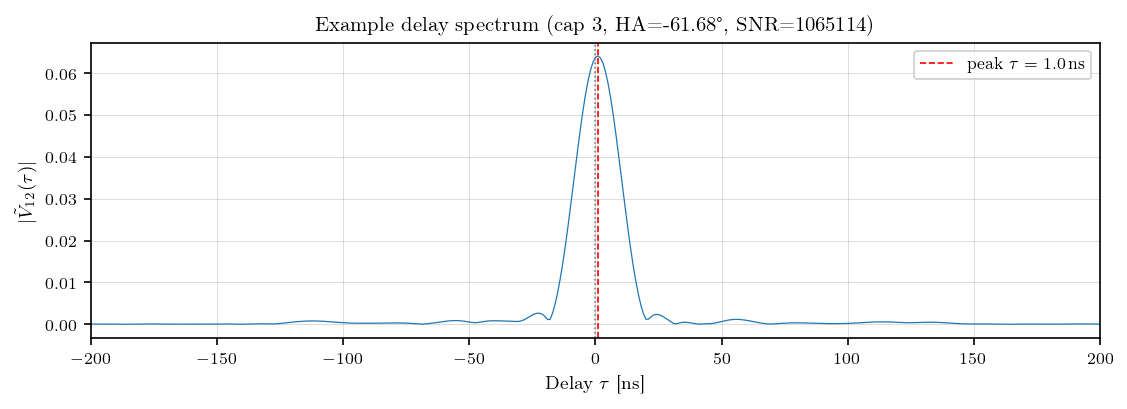

In [4]:
# ---------------------------------------------------------------------------
# Delay transform on clean passband channels
# For a point source at geometric delay τ_g, the cross-correlation spectrum
# V(f) = A exp(i 2π f τ_g).  Its IFFT peaks at τ = τ_g.
# Sun at HA ≈ -58°, Dec ≈ 0°: τ_g ≈ -(B_ew/c) sin(58°) ≈ -53 ns for B_ew ≈ 19 m.
# ---------------------------------------------------------------------------

N_PAD = 4096

f_clean_hz   = F_HZ[clean_mask]
n_clean      = clean_mask.sum()
BW_HZ        = n_clean * DF_HZ
DELAY_RES_NS = 1 / BW_HZ * 1e9
DELAY_MAX_NS = 200.0

delay_axis_ns = np.fft.fftshift(np.fft.fftfreq(N_PAD, d=DF_HZ)) * 1e9

print(f'Clean channels  : {n_clean}')
print(f'Bandwidth       : {BW_HZ/1e6:.1f} MHz')
print(f'Delay resolution: {DELAY_RES_NS:.2f} ns  (padded to {N_PAD})')

win     = np.hanning(n_clean)
k_clean = np.where(clean_mask)[0]

tau_peak_ns    = np.zeros(len(files_s))
delay_peak_snr = np.zeros(len(files_s))

for i, f in enumerate(files_s):
    v = f['corr'][clean_mask] * win
    v_pad = np.zeros(N_PAD, dtype=complex)
    v_pad[k_clean] = v
    delay_spec = np.fft.fftshift(np.fft.ifft(v_pad))
    power = np.abs(delay_spec)**2

    in_win = np.abs(delay_axis_ns) <= DELAY_MAX_NS
    idx_peak = np.argmax(power * in_win)
    tau_peak_ns[i] = delay_axis_ns[idx_peak]

    noise_power = power[~in_win].mean() if (~in_win).any() else power.mean()
    delay_peak_snr[i] = power[idx_peak] / noise_power if noise_power > 0 else 0

print(f'\nDelay peak statistics:')
print(f'  τ_peak range : {tau_peak_ns.min():.1f} – {tau_peak_ns.max():.1f} ns')
print(f'  SNR range    : {delay_peak_snr.min():.1f} – {delay_peak_snr.max():.1f}')
print(f'  Median SNR   : {np.median(delay_peak_snr):.1f}')

# Example: capture with highest SNR
idx_ex  = np.argmax(delay_peak_snr)
v_ex    = files_s[idx_ex]['corr'][clean_mask] * win
v_pad_ex = np.zeros(N_PAD, dtype=complex); v_pad_ex[k_clean] = v_ex
dspec_ex = np.fft.fftshift(np.fft.ifft(v_pad_ex))

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
ax.plot(delay_axis_ns, np.abs(dspec_ex), lw=LW_FINE, color=PRIMARY_COLOR)
ax.axvline(tau_peak_ns[idx_ex], color='red', lw=LW_GUIDE, ls='--',
           label=rf'peak $\tau={tau_peak_ns[idx_ex]:.1f}$\,ns')
ax.axvline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls=':')
ax.set_xlim(-DELAY_MAX_NS, DELAY_MAX_NS)
ax.set_xlabel(r'Delay $\tau$ [ns]')
ax.set_ylabel(r'$|\tilde{V}_{12}(\tau)|$')
ax.set_title(f'Example delay spectrum  (cap {idx_ex},  HA={ha_deg[idx_ex]:.2f}°,  SNR={delay_peak_snr[idx_ex]:.0f})')
ax.legend()
fig.tight_layout()
plt.show()

Using 138 / 184 captures (SNR ≥ 528436.6)


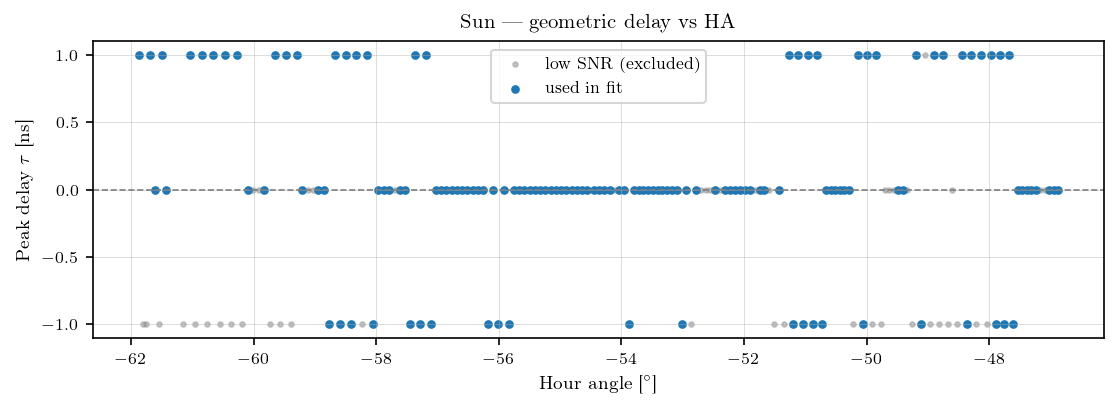

In [5]:
# ---------------------------------------------------------------------------
# τ_peak vs HA
# Expected: τ_g(HA) = (B_ew/c) cos(dec) sin(HA) — a sinusoid, but over
# a narrow HA range it appears nearly linear.
# ---------------------------------------------------------------------------

SNR_CUT = np.percentile(delay_peak_snr, 25)
good    = delay_peak_snr >= SNR_CUT
print(f'Using {good.sum()} / {len(files_s)} captures (SNR ≥ {SNR_CUT:.1f})')

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
ax.scatter(ha_deg[~good], tau_peak_ns[~good], s=SCATTER_S_FINE*0.5,
           color=NEUTRAL_COLOR, alpha=0.4, label='low SNR (excluded)')
ax.scatter(ha_deg[good],  tau_peak_ns[good],  s=SCATTER_S_FINE,
           color=PRIMARY_COLOR, label='used in fit')
ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--')
ax.set_xlabel(r'Hour angle [$^\circ$]')
ax.set_ylabel(r'Peak delay $\tau$ [ns]')
ax.set_title(r'Sun — geometric delay vs HA')
ax.legend()
fig.tight_layout()
plt.show()

┌─── Baseline fit result (delay transform) ────────────┐
│  B_ew       = -0.774 ± 0.445 m
│  τ_cable    = -1.93 ns  (cable delay offset)
│  Residual   = 0.63 ns  rms
│  N captures = 138
│  HA span    = 14.99°
└──────────────────────────────────────────────────────┘


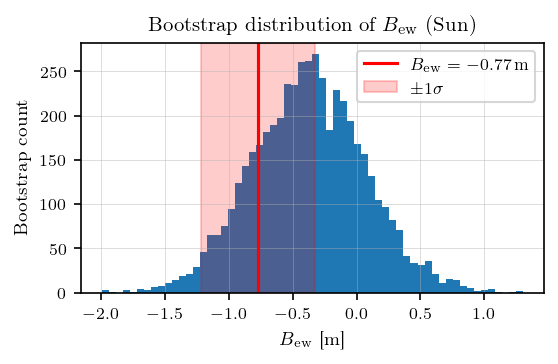

In [6]:
# ---------------------------------------------------------------------------
# Baseline fit: τ_g = (B_ew/c) cos(dec_i) sin(HA_i) + τ_cable
#
# Because the Sun's Dec varies slowly, use per-capture dec in the design
# matrix: x_i = cos(dec_i) sin(HA_i)
# ---------------------------------------------------------------------------

dec_rad_arr = np.deg2rad(sun_dec_arr)
x_good = np.cos(dec_rad_arr[good]) * np.sin(ha_rad[good])   # (B_ew/c) × this = τ_g
tau_good = tau_peak_ns[good] * 1e-9

# Weighted least-squares (weight by SNR)
w = delay_peak_snr[good]
w = w / w.sum()

X = np.column_stack([x_good, np.ones(good.sum())])
W = np.diag(w)
beta, _, _, _ = np.linalg.lstsq(W @ X, W @ tau_good, rcond=None)
A_fit, tau_cable = beta

B_ew = A_fit * C

# Residuals
tau_model_good = A_fit * x_good + tau_cable
residuals_ns   = (tau_good - tau_model_good) * 1e9
rms_ns = np.sqrt(np.mean(residuals_ns**2))

# Bootstrap uncertainty
rng    = np.random.default_rng(42)
N_boot = 5000
b_boot = np.zeros(N_boot)
n_good = good.sum()
for b in range(N_boot):
    samp = rng.choice(n_good, n_good, replace=True)
    Xi   = np.column_stack([x_good[samp], np.ones(n_good)])
    ti   = tau_good[samp]
    try:
        bet, _, _, _ = np.linalg.lstsq(Xi, ti, rcond=None)
        b_boot[b] = bet[0] * C
    except Exception:
        b_boot[b] = np.nan

b_boot   = b_boot[np.isfinite(b_boot)]
B_ew_std = b_boot.std()

print(f'┌─── Baseline fit result (delay transform) ────────────┐')
print(f'│  B_ew       = {B_ew:.3f} ± {B_ew_std:.3f} m')
print(f'│  τ_cable    = {tau_cable*1e9:.2f} ns  (cable delay offset)')
print(f'│  Residual   = {rms_ns:.2f} ns  rms')
print(f'│  N captures = {good.sum()}')
print(f'│  HA span    = {ha_deg[good].max()-ha_deg[good].min():.2f}°')
print(f'└──────────────────────────────────────────────────────┘')

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN * 0.5, 2.5))
ax.hist(b_boot, bins=60, color=PRIMARY_COLOR, edgecolor='none')
ax.axvline(B_ew, color='red', lw=1.5, label=rf'$B_{{\rm ew}}={B_ew:.2f}$\,m')
ax.axvspan(B_ew - B_ew_std, B_ew + B_ew_std, alpha=0.2, color='red', label=r'$\pm 1\sigma$')
ax.set_xlabel(r'$B_{\rm ew}$ [m]')
ax.set_ylabel('Bootstrap count')
ax.set_title('Bootstrap distribution of $B_{\\rm ew}$  (Sun)')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

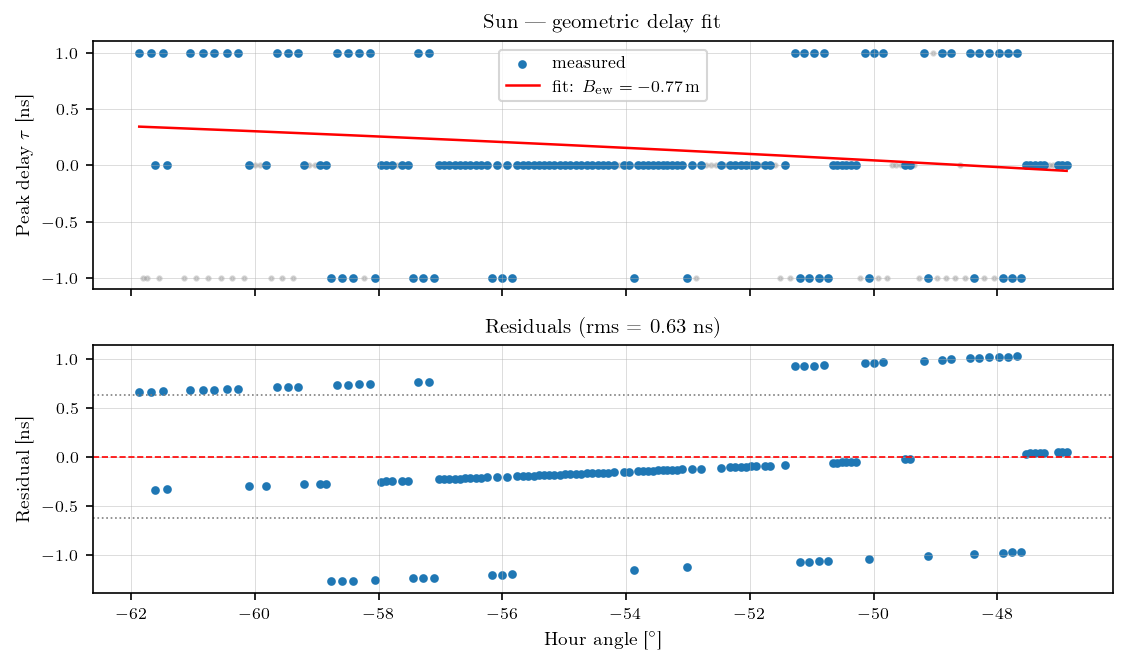

In [7]:
# ---------------------------------------------------------------------------
# Fit overlay and residuals
# ---------------------------------------------------------------------------

ha_fine   = np.linspace(ha_deg.min(), ha_deg.max(), 400)
dec_mean  = sun_dec_arr.mean()
tau_fine  = (A_fit * np.cos(np.deg2rad(dec_mean)) * np.sin(np.deg2rad(ha_fine)) + tau_cable) * 1e9

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.5), sharex=True)

axes[0].scatter(ha_deg[~good], tau_peak_ns[~good], s=SCATTER_S_FINE*0.4,
                color=NEUTRAL_COLOR, alpha=0.3)
axes[0].scatter(ha_deg[good],  tau_peak_ns[good],  s=SCATTER_S_FINE,
                color=PRIMARY_COLOR, label='measured')
axes[0].plot(ha_fine, tau_fine, lw=1.2, color='red',
             label=rf'fit: $B_{{\rm ew}}={B_ew:.2f}$\,m')
axes[0].set_ylabel(r'Peak delay $\tau$ [ns]')
axes[0].legend(fontsize=8)
axes[0].set_title(r'Sun — geometric delay fit')

axes[1].scatter(ha_deg[good], residuals_ns, s=SCATTER_S_FINE, color=PRIMARY_COLOR)
axes[1].axhline(0,      color='red',         lw=LW_GUIDE, ls='--')
axes[1].axhline( rms_ns, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls=':')
axes[1].axhline(-rms_ns, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls=':')
axes[1].set_ylabel(r'Residual [ns]')
axes[1].set_xlabel(r'Hour angle [$^\circ$]')
axes[1].set_title(f'Residuals  (rms = {rms_ns:.2f} ns)')

fig.tight_layout()
plt.show()

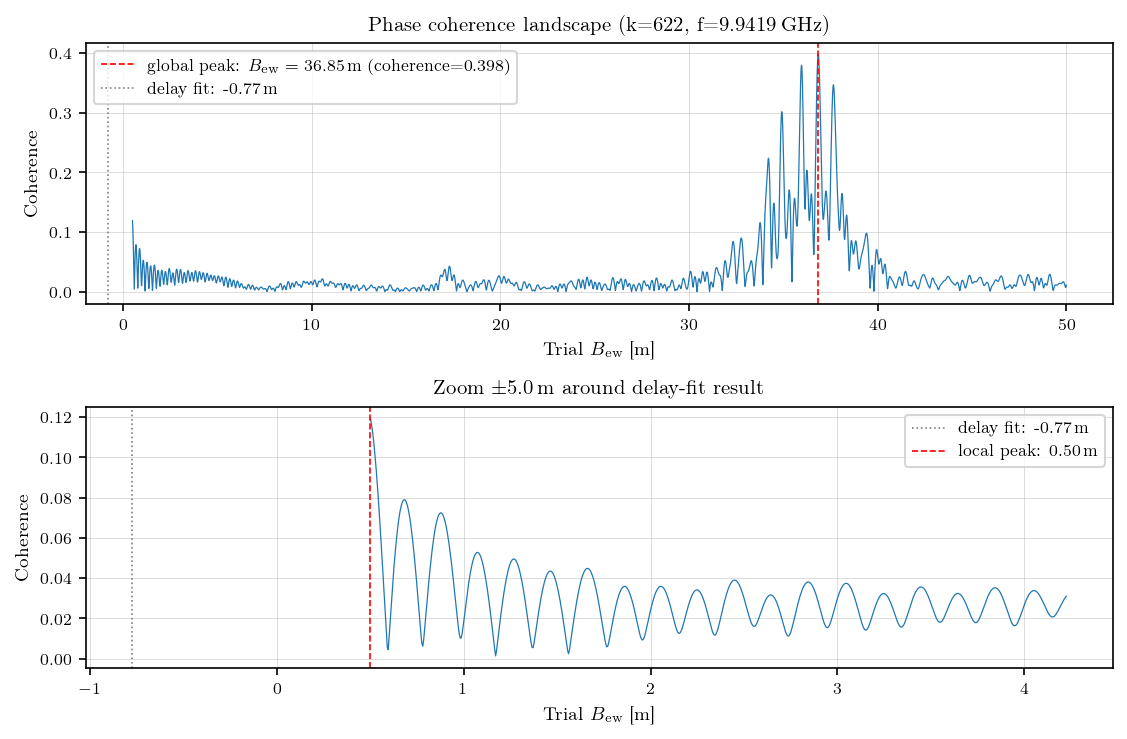

Delay transform : B_ew = -0.774 ± 0.445 m
Phase search    : B_ew = 36.850 m  (global,  coherence=0.3979)
Phase search    : B_ew = 0.500 m  (local near delay fit)


In [8]:
# ---------------------------------------------------------------------------
# Cross-check: coherent phase grid search
#
# For each trial B_ew, compute the fringe phase model at every capture using
# the per-capture Sun RA/Dec (important — Sun moves ~1°/day):
#   φ_model(i) = (2π f / c) B_ew cos(dec_i) sin(HA_i)
# and measure coherence = |mean(exp(i(φ_meas − φ_model)))|.
#
# Note: the narrow HA span (≈5°) means many B_ew values produce near-identical
# phase sequences; expect a comb of peaks spaced by
#   ΔB ≈ c / (f × cos(dec) × Δsin(HA))
# The delay transform result above selects the correct alias.
# ---------------------------------------------------------------------------

k_peak   = int(np.argmax(all_amp.mean(axis=0)))
f_peak   = F_HZ[k_peak]
vis_peak = np.array([f['corr'][k_peak] for f in files_s])
phi_meas = np.angle(vis_peak)

b_scan    = np.arange(0.5, 50.0, 0.005)
coherence = np.zeros(len(b_scan))
for j, b in enumerate(b_scan):
    phi_mod = ((2 * np.pi * f_peak / C)
               * b * np.cos(dec_rad_arr) * np.sin(ha_rad))
    coherence[j] = np.abs(np.exp(1j * (phi_meas - phi_mod)).mean())

best_idx = np.argmax(coherence)
B_phase  = b_scan[best_idx]

# Zoom window around delay-fit result
B_ZOOM = 5.0
zoom = np.abs(b_scan - B_ew) < B_ZOOM

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 5.0))

# Full scan
axes[0].plot(b_scan, coherence, lw=LW_FINE, color=PRIMARY_COLOR)
axes[0].axvline(B_phase, color='red', lw=LW_GUIDE, ls='--',
                label=rf'global peak: $B_{{\rm ew}}={B_phase:.2f}$\,m  (coherence={coherence[best_idx]:.3f})')
if np.isfinite(B_ew):
    axes[0].axvline(B_ew, color='gray', lw=LW_GUIDE, ls=':',
                    label=rf'delay fit: {B_ew:.2f}\,m')
axes[0].set_xlabel(r'Trial $B_{\rm ew}$ [m]')
axes[0].set_ylabel('Coherence')
axes[0].set_title(rf'Phase coherence landscape  (k={k_peak},  f={f_peak/1e9:.4f}\,GHz)')
axes[0].legend(fontsize=8)

# Zoomed around delay fit
axes[1].plot(b_scan[zoom], coherence[zoom], lw=LW_FINE, color=PRIMARY_COLOR)
if np.isfinite(B_ew):
    axes[1].axvline(B_ew, color='gray', lw=LW_GUIDE, ls=':',
                    label=rf'delay fit: {B_ew:.2f}\,m')
zoom_best = np.argmax(coherence[zoom])
B_zoom_peak = b_scan[zoom][zoom_best]
axes[1].axvline(B_zoom_peak, color='red', lw=LW_GUIDE, ls='--',
                label=rf'local peak: {B_zoom_peak:.2f}\,m')
axes[1].set_xlabel(r'Trial $B_{\rm ew}$ [m]')
axes[1].set_ylabel('Coherence')
axes[1].set_title(rf'Zoom ±{B_ZOOM}\,m around delay-fit result')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f'Delay transform : B_ew = {B_ew:.3f} ± {B_ew_std:.3f} m')
print(f'Phase search    : B_ew = {B_phase:.3f} m  (global,  coherence={coherence[best_idx]:.4f})')
print(f'Phase search    : B_ew = {B_zoom_peak:.3f} m  (local near delay fit)')